---
title: Implementasi Eigenfaces
date: 2026-05-24
---

---

# Informasi Awal

## Tautan File Jupyter Notebook

Jika anda ingin melihat secara langsung file Jupyter Notebook (.ipynb), anda dapat mengunjungi [tautan ini](https://github.com/Nacxht/komputasi-aljabar-linier/blob/main/src/eigenfaces/eigenfaces.ipynb).

## Library yang Digunakan

Berikut adalah daftar dari library yang saya gunakan:

- matplotlib
- opencv-python
- scikit learn
- numpy

## Dataset yang Digunakan

Untuk tugas ini, saya menggunakan dataset yang berjudul "_AT&T Database of Faces_", dan saya mengunduhnya dari Kaggle. Anda dapat mengunjungi halaman datasetnya dengan mengunjungi [tautan ini](https://www.kaggle.com/datasets/kasikrit/att-database-of-faces)

---

# Program Inti

## Import Library

Pertama-tama, kita menyiapkan semua perangkat yang dibutuhkan. Kita mengimpor modul `os` untuk mengelola path direktori, `cv2` (OpenCV) untuk membaca dan memanipulasi gambar, `numpy` untuk komputasi matriks tingkat lanjut, serta `matplotlib.pyplot` untuk kebutuhan visualisasi.

In [2]:
import os
import matplotlib.pyplot as plt
import cv2
import random
import numpy as np

## Pengecekan Awal Dataset

Memastikan path direktori "dataset" sudah terbaca dengan benar oleh sistem sebelum melanjutkan ke bagian yang lebih lanjut.

In [3]:
path = "dataset"

for root, dirs, files in os.walk(path):
    print(root)
    break

dataset


## Eksplorasi Struktur Dataset
Supaya lebih jelas, kita menelusuri isi folder dataset. Kode ini akan menampilkan nama folder setiap subjek beserta jumlah file gambar di dalamnya. Ini berguna untuk memastikan data setiap orang konsisten jumlahnya.

In [4]:
for root, dirs, files in os.walk(path):
    print("Folder:", root)
    print("Jumlah file:", len(files))
    print("-"*40)

Folder: dataset
Jumlah file: 1
----------------------------------------
Folder: dataset/s23
Jumlah file: 10
----------------------------------------
Folder: dataset/s20
Jumlah file: 10
----------------------------------------
Folder: dataset/s4
Jumlah file: 10
----------------------------------------
Folder: dataset/s2
Jumlah file: 10
----------------------------------------
Folder: dataset/s33
Jumlah file: 10
----------------------------------------
Folder: dataset/s16
Jumlah file: 10
----------------------------------------
Folder: dataset/s34
Jumlah file: 10
----------------------------------------
Folder: dataset/s38
Jumlah file: 10
----------------------------------------
Folder: dataset/s5
Jumlah file: 10
----------------------------------------
Folder: dataset/s11
Jumlah file: 10
----------------------------------------
Folder: dataset/s19
Jumlah file: 10
----------------------------------------
Folder: dataset/s18
Jumlah file: 10
----------------------------------------
Folder:

## Menampilkan Sampel Acak

Melihat salah satu wujud dari dataset dengan cara memilih satu folder orang secara acak, dan mengambil satu gambarnya, lalu menampilkannya sebagai gambar *grayscale* (hitam-putih).

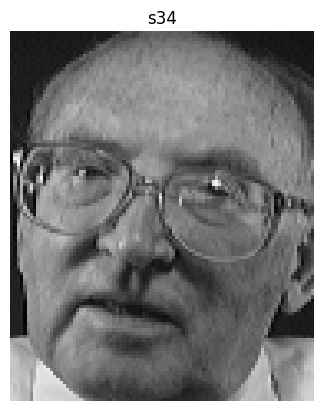

In [5]:
sample_class = random.choice(os.listdir(path))
sample_folder = os.path.join(path, sample_class)

sample_img = random.choice(os.listdir(sample_folder))
img_path = os.path.join(sample_folder, sample_img)

img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

plt.imshow(img, cmap='gray')
plt.title(f"{sample_class}")
plt.axis("off")
plt.show()

## Standarisasi Ukuran Gambar

Kita mendefinisikan ukuran standar gambar, yaitu lebar 92 dan tinggi 112 piksel. Ukuran ini mengikuti standar umum untuk *ORL Face Database* agar bentuk matriks yang kita proses seragam.

In [ ]:
IMG_SIZE = (92, 112)

## Pra-pemrosesan Data (Flattening)

Ini adalah salah satu langkah paling penting:
* Kita membaca setiap gambar dalam dataset.
* Gambar di-*resize* sesuai ukuran standar.
* Melakukan proses *flattening*, yaitu meratakan piksel matriks 2D menjadi vektor 1D. Vektor ini sangat krusial karena Singular Value Decomposition (SVD) membutuhkan matriks dua dimensi sebagai input.
* Data wajah disimpan di array `X`, sedangkan nama/folder orang disimpan di array `y`.

In [ ]:
X = []   # data wajah
y = []   # label orang (s1, s2, dst)

for person in os.listdir(path):
    person_path = os.path.join(path, person)

    if not os.path.isdir(person_path):
        continue

    for img_name in os.listdir(person_path):
        img_path = os.path.join(person_path, img_name)

        # baca grayscale
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        # resize gambar
        img = cv2.resize(img, IMG_SIZE)

        # flatten gambar
        img_vector = img.flatten()

        X.append(img_vector)
        y.append(person)

X = np.array(X, dtype='float32')
y = np.array(y)

print("Shape X:", X.shape)
print("Shape y:", y.shape)

Shape X: (400, 10304)
Shape y: (400,)


## Fungsi Pembantu: Menampilkan Gambar

Karena gambar kita sudah diubah menjadi array 1D, kita membuat fungsi `show_image` untuk mengembalikannya lagi ke bentuk 2D (112 baris x 92 kolom) agar bisa divisualisasikan oleh Matplotlib.

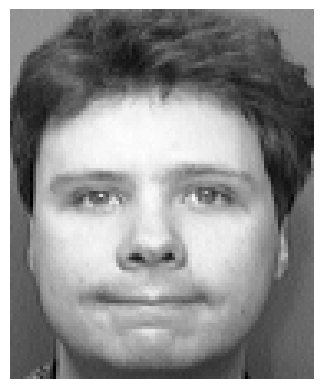

In [8]:
def show_image(vector):
    plt.imshow(vector.reshape(112, 92), cmap='gray')
    plt.axis("off")
    plt.show()

show_image(X[0])

## Menghitung Rata-rata Wajah (Mean Face)

Dalam algoritma Eigenfaces, kita perlu menemukan wujud "wajah rata-rata" dari seluruh data. Kita menghitung nilai rata-rata tiap kolom piksel melintasi seluruh sampel di dalam `X`.

In [9]:
mean_face = np.mean(X, axis=0)

print(mean_face.shape)

(10304,)


## Visualisasi Mean Face
Setelah mendapatkan *mean face*, kita langsung memvisualisasikannya. Gambar ini merupakan representasi gabungan fitur wajah dari seluruh orang di dataset kita.

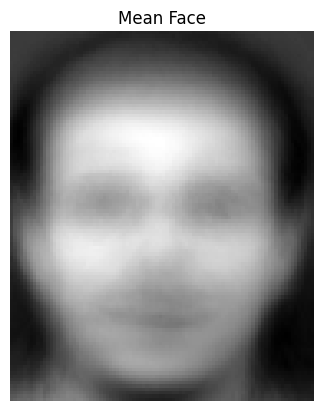

In [10]:
plt.imshow(mean_face.reshape(112, 92), cmap='gray')
plt.title("Mean Face")
plt.axis("off")
plt.show()

## Pemusatan Data (Mean Centering)

Kita mengurangi setiap gambar di dalam matriks `X` dengan *mean face*. Proses ini menghilangkan fitur umum wajah (seperti posisi mata dan hidung yang rata-rata sama) sehingga model bisa fokus pada fitur *unik* yang membedakan satu wajah dengan wajah lainnya.

In [11]:
X_centered = X - mean_face

print(X_centered.shape)

(400, 10304)


## Dekomposisi SVD
Di sini sihir aljabar linearnya bekerja. Kita melakukan *Singular Value Decomposition* (SVD) pada matriks data yang sudah di-centering. Proses ini menghasilkan matriks $U$, nilai singular $S$, dan matriks $V^t$ (vektor singular kanan) yang merepresentasikan komponen-komponen utama dari data wajah kita.

Untuk menghitung atau kalkulasi SVD, disini saya menggunakan modul `linalg.svd()` yang disediakan oleh NumPy

In [12]:
U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)

print("Shape U :", U.shape)
print("Shape S :", S.shape)
print("Shape Vt:", Vt.shape)

Shape U : (400, 400)
Shape S : (400,)
Shape Vt: (400, 10304)


## Ekstraksi Eigenfaces
Matriks $V^t$ hasil SVD ini pada dasarnya adalah kumpulan vektor eigen kita, atau biasa disebut *Eigenfaces*.

In [13]:
eigenfaces = Vt
print(eigenfaces.shape)

(400, 10304)


## Fungsi Pembantu: Menampilkan Eigenface

Mirip seperti `show_image`, kita membuat fungsi khusus `show_eigenface` untuk menampilkan setiap vektor eigen menjadi gambar 2D agar bisa dilihat secara visual.

In [14]:
def show_eigenface(vector, title=""):
    plt.imshow(vector.reshape(112, 92), cmap='gray')
    plt.title(title)
    plt.axis("off")
    plt.show()

## Melihat 10 Eigenface Teratas

Kita melakukan *looping* untuk melihat wujud 10 eigenface pertama. Gambar-gambar ini sekilas terlihat seperti hantu, namun secara matematis mereka mewakili pola variasi wajah yang paling dominan di dataset.

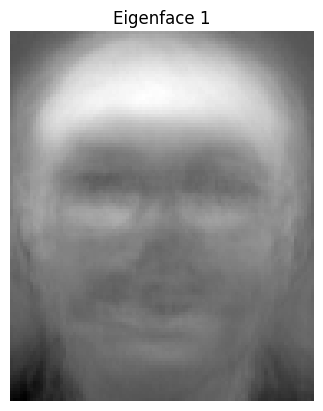

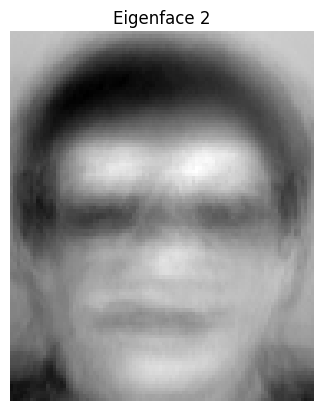

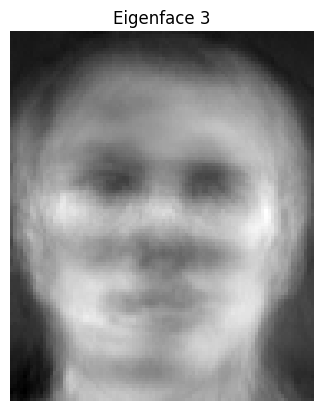

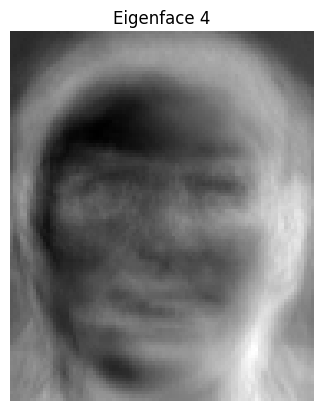

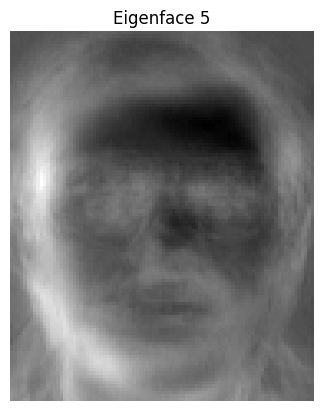

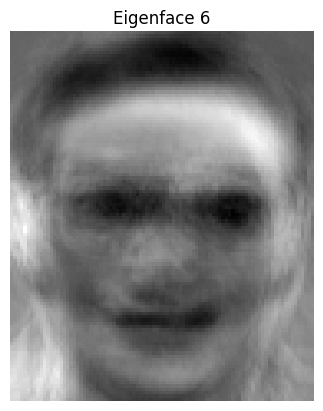

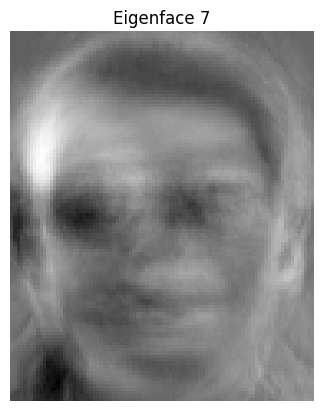

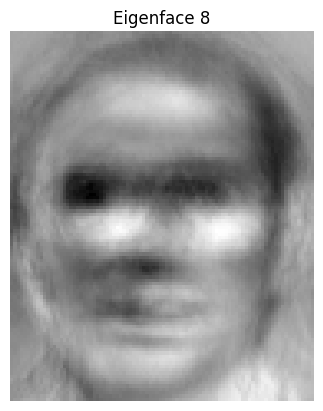

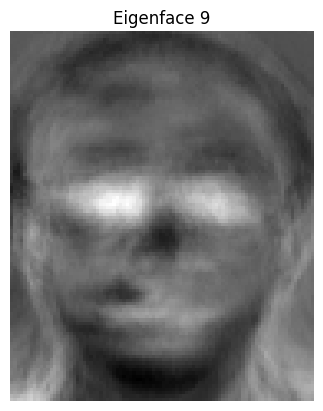

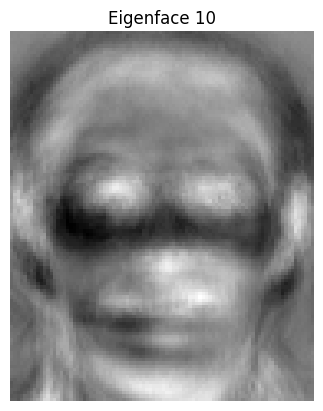

In [15]:
for i in range(10):
    show_eigenface(eigenfaces[i], f"Eigenface {i+1}")

## Pemilihan Fitur Utama (Dimensionality Reduction)

Kita tidak butuh semua komponen untuk mengenali wajah. Di sini kita memotong dimensi fitur dengan hanya mengambil `k = 50` eigenfaces teratas. Komponen ini sudah cukup mewakili sebagian besar informasi penting.

In [16]:
k = 50  # bisa 20, 50, atau 100
eigenfaces_k = Vt[:k]

## Proyeksi Data ke Ruang Eigen

Data wajah yang awalnya punya puluhan ribu dimensi piksel sekarang diproyeksikan (dikalikan dengan matriks eigenfaces kita) menjadi hanya 50 dimensi. Data ini jadi sangat ringan untuk diproses.

In [17]:
X_proj = np.dot(X_centered, eigenfaces_k.T)

print(X_proj.shape)

(400, 50)


## Analisis Distribusi Energi

Kode ini memvisualisasikan grafik nilai singular. Kurva yang menurun tajam ini menunjukkan bahwa beberapa komponen pertama memegang hampir seluruh informasi (energi) dari dataset, memperkuat alasan kenapa kita hanya perlu mengambil nilai `k` yang kecil.

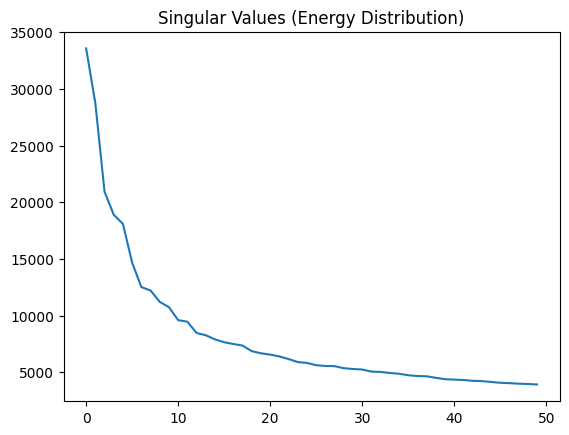

In [18]:
plt.plot(S[:50])
plt.title("Singular Values (Energy Distribution)")
plt.show()

## Pembagian Data Latih dan Uji

Agar model bisa diuji secara objektif, kita memecah data. Menggunakan logika sederhana, kita mengambil 7 gambar pertama dari masing-masing orang sebagai data latih (train) dan sisanya menjadi data uji (test).

In [19]:
from collections import defaultdict

train_X = []
train_y = []

test_X = []
test_y = []

counter = defaultdict(int)

for i in range(len(X)):
    label = y[i]

    counter[label] += 1

    if counter[label] <= 7:
        train_X.append(X[i])
        train_y.append(label)
    else:
        test_X.append(X[i])
        test_y.append(label)

train_X = np.array(train_X)
test_X = np.array(test_X)

print("Train:", train_X.shape)
print("Test :", test_X.shape)

Train: (280, 10304)
Test : (120, 10304)


## Centering untuk Train dan Test

Data yang sudah dipecah wajib dipusatkan kembali dengan cara dikurangi oleh *mean face* yang kita hitung di awal.

In [20]:
train_X_centered = train_X - mean_face
test_X_centered = test_X - mean_face

## Deklarasi Ulang Batas k

Hanya menegaskan ulang penggunaan `k = 50` eigenfaces untuk proses selanjutnya.

In [21]:
k = 50

eigenfaces_k = Vt[:k]

## Proyeksi Data Latih
Data latih yang sudah di-centering kita transformasikan atau proyeksikan ke ruang eigen.

In [22]:
train_proj = np.dot(train_X_centered, eigenfaces_k.T)

print(train_proj.shape)

(280, 50)


## Proyeksi Data Uji

Sama halnya dengan data latih, data uji juga wajib ditransformasikan ke dimensi ruang eigen yang sama agar bisa diklasifikasikan nanti.

In [23]:
test_proj = np.dot(test_X_centered, eigenfaces_k.T)

print(test_proj.shape)

(120, 50)


In [24]:
test_proj = np.dot(test_X_centered, eigenfaces_k.T)

print(test_proj.shape)

(120, 50)


## Kalkulasi Jarak Kemiripan

Kita mendefinisikan fungsi `euclidean_distance` yang akan menghitung seberapa "jauh" jarak matematis antara dua gambar di ruang eigen. Semakin dekat jaraknya, semakin mirip wajahnya.

Untuk menghitung _euclidean distance_, disini saya menggunakan modul `linalg.norm()` yang disediakan oleh NumPy

In [25]:
def euclidean_distance(a, b):
    return np.linalg.norm(a - b)

## Proses Pengenalan Wajah

Di sinilah klasifikasi bekerja (mirip pendekatan K-Nearest Neighbors dengan K=1). Untuk setiap gambar di data uji, kita mengukur jaraknya ke seluruh gambar di data latih. Gambar latih dengan jarak terpendek dianggap sebagai kandidat wajah yang paling cocok (prediksi).

In [26]:
predictions = []

for i in range(len(test_proj)):
    distances = []

    for j in range(len(train_proj)):
        dist = euclidean_distance(test_proj[i], train_proj[j])
        distances.append(dist)

    idx_min = np.argmin(distances)
    predictions.append(train_y[idx_min])

predictions = np.array(predictions)

## Evaluasi Akurasi

Kita membandingkan label hasil prediksi dengan label asli data uji. Dengan rasio yang tepat, kode ini menghitung dan mencetak persentase keakuratan model kita.

In [27]:
accuracy = np.mean(predictions == test_y)

print("Accuracy:", accuracy * 100, "%")

Accuracy: 98.33333333333333 %


## Fungsi Visualisasi Prediksi

Fungsi `show_result` ini bertugas menampilkan wujud gambar data uji lengkap dengan judul teks yang berisi tebakan label/nama orang dari model kita.

In [28]:
def show_result(test_vec, pred_label):
    plt.imshow(test_vec.reshape(112, 92), cmap='gray')
    plt.title(f"Predicted: {pred_label}")
    plt.axis("off")
    plt.show()

## Peninjauan Hasil Secara Visual

Terakhir, kita melakukan *looping* untuk melihat 5 gambar pertama dari data uji secara berdampingan dengan hasil prediksi algoritmanya.

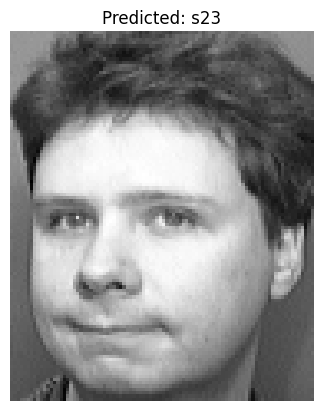

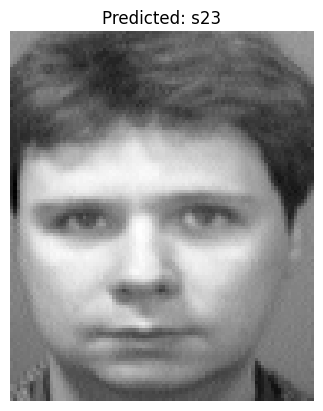

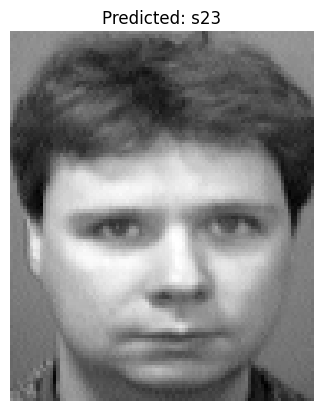

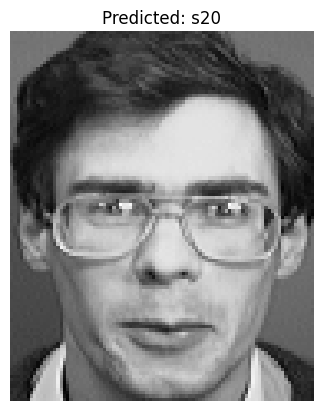

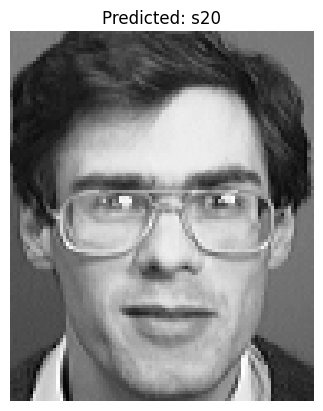

In [29]:
for i in range(5):
    show_result(test_X[i], predictions[i])